# 1. Import Libraries

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# 2. Load Dataset

In [76]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


# 3. Data Preprocessing

In [77]:
df.shape

(2640, 12)

In [78]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [80]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [81]:
df.duplicated().sum()

np.int64(0)

In [82]:
df.drop_duplicates(inplace=True)

print("Duplicates Removed")

Duplicates Removed


In [83]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


# 4. Exploratory Data Analysis (EDA)

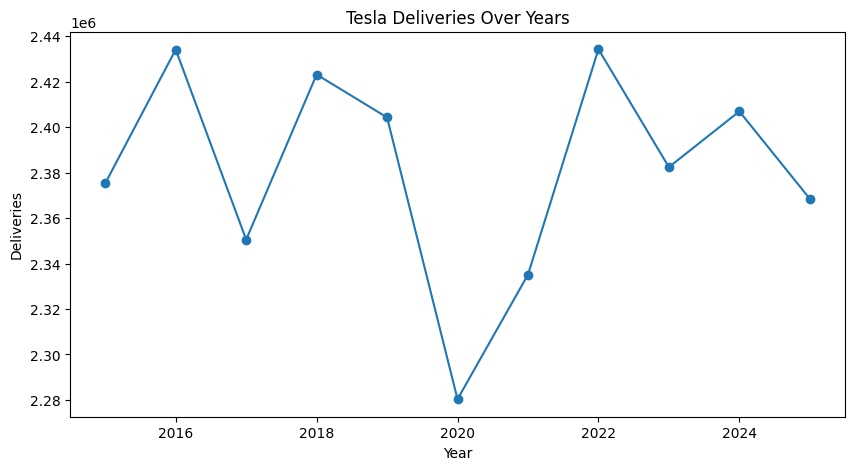

In [84]:
yearly = df.groupby("Year")["Estimated_Deliveries"].sum()

plt.figure(figsize=(10,5))
yearly.plot(marker='o')
plt.title("Tesla Deliveries Over Years")
plt.xlabel("Year")
plt.ylabel("Deliveries")
plt.show()

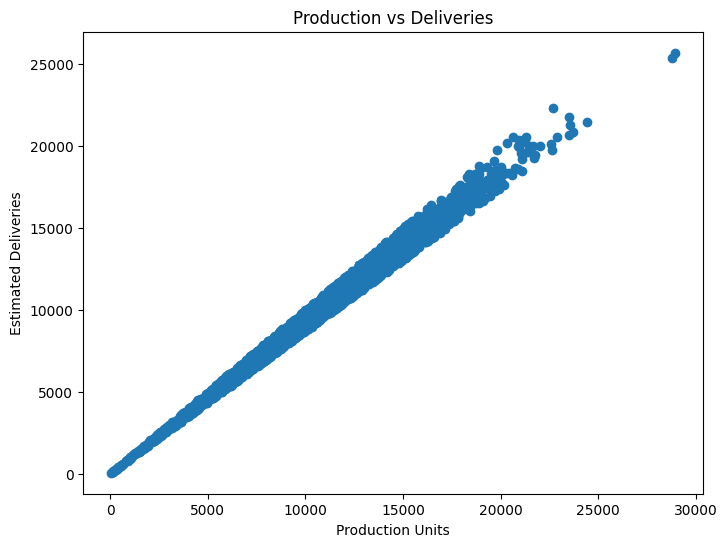

In [85]:
plt.figure(figsize=(8,6))
plt.scatter(df["Production_Units"],
            df["Estimated_Deliveries"])

plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")
plt.title("Production vs Deliveries")
plt.show()

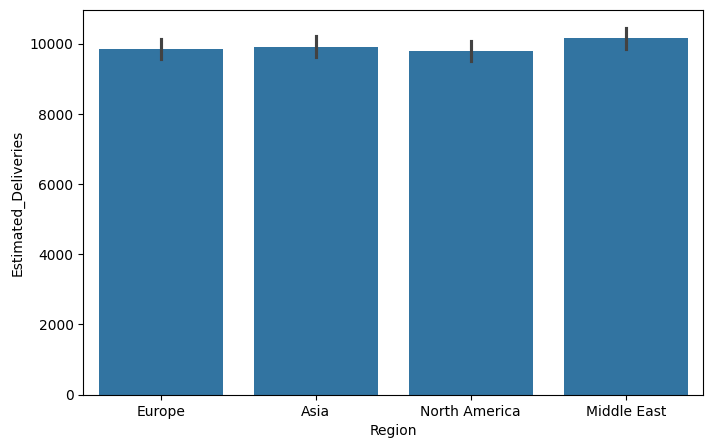

In [86]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Region",
    y="Estimated_Deliveries",
    data=df
)

plt.show()

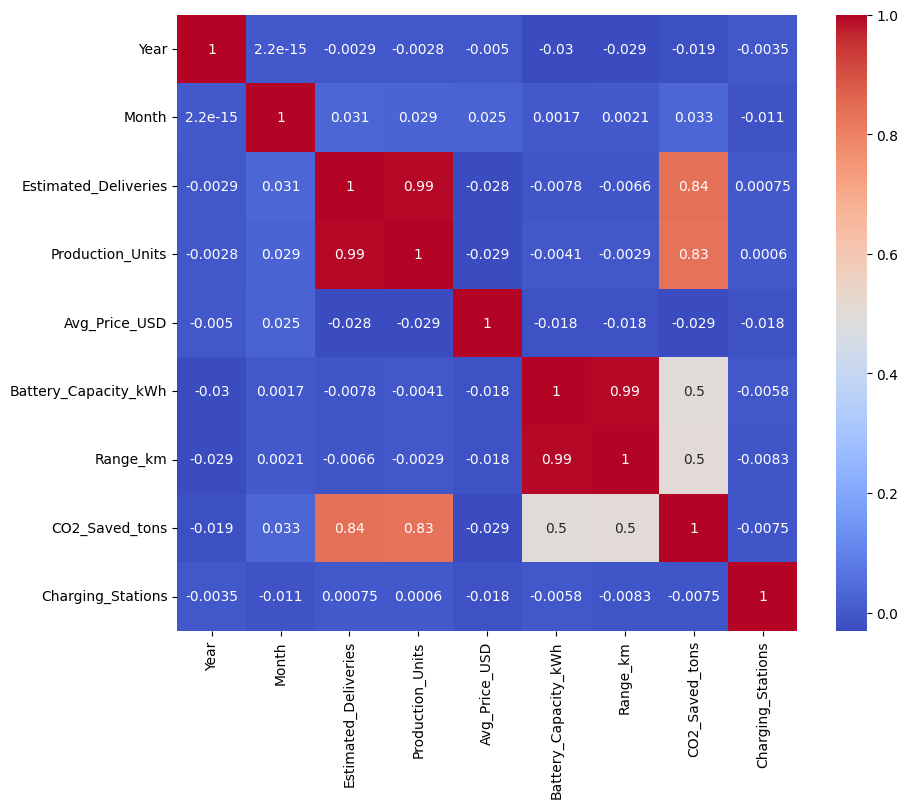

In [87]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

# 5. Feature Engineering

In [88]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) +
    "-" +
    df["Month"].astype(str)
)

In [89]:
df["Delivery_Efficiency"] = (
    df["Estimated_Deliveries"] /
    df["Production_Units"]
)

In [90]:
df["Price_Per_KM"] = (
    df["Avg_Price_USD"] /
    df["Range_km"]
)

In [91]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Delivery_Efficiency,Price_Per_KM
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01,0.984600,131.923679
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01,0.911864,142.022032
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01,0.915334,245.598583
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01,0.896594,125.414199
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01,0.914087,173.747020


# 6. Data Encoding and Preparation

In [92]:
df = pd.get_dummies(
    df,
    columns=["Region","Model"],
    drop_first=True
)

In [93]:
X = df.drop(
    ["Estimated_Deliveries","Date"],
    axis=1
)

y = df["Estimated_Deliveries"]

# 7. Regression Model Building

In [94]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [95]:
print(X.dtypes)

Year                      int64
Month                     int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
Delivery_Efficiency     float64
Price_Per_KM            float64
Region_Europe              bool
Region_Middle East         bool
Region_North America       bool
Model_Model 3              bool
Model_Model S              bool
Model_Model X              bool
Model_Model Y              bool
dtype: object


In [96]:
df = pd.get_dummies(
    df,
    columns=["Source_Type"],
    drop_first=True
)

In [97]:
print(df.dtypes)

Year                                         int64
Month                                        int64
Estimated_Deliveries                         int64
Production_Units                             int64
Avg_Price_USD                              float64
Battery_Capacity_kWh                         int64
Range_km                                     int64
CO2_Saved_tons                             float64
Charging_Stations                            int64
Date                                datetime64[ns]
Delivery_Efficiency                        float64
Price_Per_KM                               float64
Region_Europe                                 bool
Region_Middle East                            bool
Region_North America                          bool
Model_Model 3                                 bool
Model_Model S                                 bool
Model_Model X                                 bool
Model_Model Y                                 bool
Source_Type_Interpolated (Month

In [98]:
for col in X.columns:
    if X[col].dtype == "object":
        print(col)
        print(X[col].unique()[:10])

Source_Type
['Interpolated (Month)' 'Official (Quarter)' 'Estimated (Region)']


In [99]:
print(df.columns)

Index(['Year', 'Month', 'Estimated_Deliveries', 'Production_Units',
       'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations', 'Date', 'Delivery_Efficiency', 'Price_Per_KM',
       'Region_Europe', 'Region_Middle East', 'Region_North America',
       'Model_Model 3', 'Model_Model S', 'Model_Model X', 'Model_Model Y',
       'Source_Type_Interpolated (Month)', 'Source_Type_Official (Quarter)'],
      dtype='object')


In [100]:
X = df.drop(
    ["Estimated_Deliveries", "Date"],
    axis=1
)

y = df["Estimated_Deliveries"]

In [101]:
print(X.select_dtypes(include="object").columns)

Index([], dtype='object')


In [102]:
print(X_train.select_dtypes(include="object").columns)

Index(['Source_Type'], dtype='object')


In [103]:
X = df.drop(
    ["Estimated_Deliveries", "Date"],
    axis=1
)

y = df["Estimated_Deliveries"]

In [104]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [105]:
print(X_train.select_dtypes(include="object").columns)

Index([], dtype='object')


In [106]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# 8. Model Evaluation

In [107]:
predictions = model.predict(X_test)

In [108]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("MAE:",
      mean_absolute_error(y_test,predictions))

print("MSE:",
      mean_squared_error(y_test,predictions))

print("R2:",
      r2_score(y_test,predictions))

MAE: 66.58164772727271
MSE: 12429.435939583338
R2: 0.9991661615669847


# 9. Hyperparameter Tuning

In [109]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators":[100,200],
    "max_depth":[5,10,None]
}

grid = GridSearchCV(
    RandomForestRegressor(),
    params,
    cv=3,
    scoring="r2"
)

grid.fit(X_train,y_train)

,estimator,RandomForestRegressor()
,param_grid,"{'max_depth': [5, 10, ...], 'n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [110]:
print(grid.best_params_)

{'max_depth': None, 'n_estimators': 200}


# 10. Time Series Forecasting

In [111]:
ts = df.groupby("Date")[
    "Estimated_Deliveries"
].sum()

ts.head()

Date
2015-01-01    183180
2015-02-01    165053
2015-03-01    184567
2015-04-01    225623
2015-05-01    184264
Name: Estimated_Deliveries, dtype: int64

In [112]:
!pip install prophet

Defaulting to user installation because normal site-packages is not writeable
  Using cached prophet-1.3.0-py3-none-win_amd64.whl.metadata (3.6 kB)
Using cached prophet-1.3.0-py3-none-win_amd64.whl (12.1 MB)


ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'C:\\Users\\Priysha\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python313\\site-packages\\prophet\\stan_model\\cmdstan-2.37.0\\stan\\lib\\stan_math\\lib\\tbb_2020.3\\include\\tbb\\internal\\_deprecated_header_message_guard.h'
HINT: This error might have occurred since this system does not have Windows Long Path support enabled. You can find information on how to enable this at https://pip.pypa.io/warnings/enable-long-paths



In [113]:
from prophet import Prophet

forecast_df = ts.reset_index()

forecast_df.columns = [
    "ds",
    "y"
]

forecast_model = Prophet()

forecast_model.fit(
    forecast_df
)

17:12:09 - cmdstanpy - INFO - Chain [1] start processing
17:12:10 - cmdstanpy - INFO - Chain [1] done processing


In [114]:
future = forecast_model.make_future_dataframe(
    periods=12,
    freq="M"
)

forecast = forecast_model.predict(
    future
)

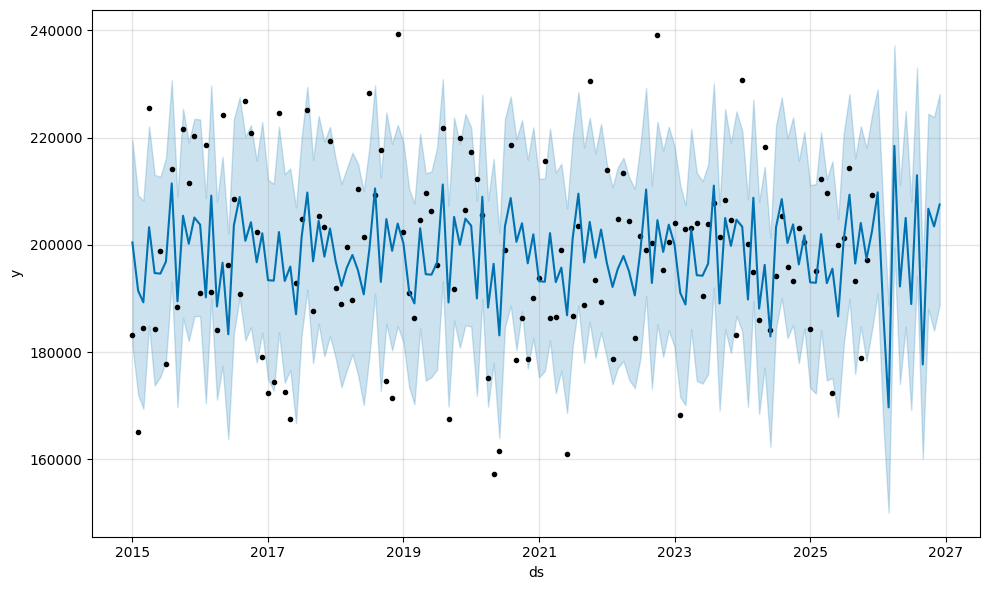

In [115]:
forecast_model.plot(
    forecast
)
plt.show()

# 11. Model Saving

In [116]:
import joblib

joblib.dump(
    grid.best_estimator_,
    "model.pkl"
)

print("Model Saved")

Model Saved


# 12. Conclusion

In [118]:
print("Project Completed Successfully")
print("Regression Model: Random Forest Regressor")
print("Hyperparameter Tuning: GridSearchCV")
print("Forecasting: Prophet")
print("Model Saved as model.pkl")

Project Completed Successfully
Regression Model: Random Forest Regressor
Hyperparameter Tuning: GridSearchCV
Forecasting: Prophet
Model Saved as model.pkl
